# Lending Message A/B Test

This notebook evaluates the quality of LLM-generated rewrites of consumer-facing lending messages, comparing them against the original message to assess their potential impact on conversion rates for short-term loan applications. 

## Part A - Experiment Analysis

Primary outcome: `doc_submitted_72h`, because the business goal is to get applicants to submit missing income documents. Clicks and responses are secondary diagnostics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, chisquare
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

app = pd.read_csv('data/applicants_experiment.csv')
variants = ['original', 'A', 'B']
primary = 'doc_submitted_72h'

print(app.info())
display(app.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   applicant_id        12000 non-null  int64 
 1   variant             12000 non-null  object
 2   channel             12000 non-null  object
 3   risk_band           12000 non-null  object
 4   days_since_start    12000 non-null  int64 
 5   missing_doc_type    12000 non-null  object
 6   delivered           12000 non-null  int64 
 7   clicked_24h         12000 non-null  int64 
 8   responded_72h       12000 non-null  int64 
 9   doc_submitted_72h   12000 non-null  int64 
 10  app_completed_7d    12000 non-null  int64 
 11  unsub_7d            12000 non-null  int64 
 12  complaint_7d        12000 non-null  int64 
 13  support_contact_7d  12000 non-null  int64 
dtypes: int64(10), object(4)
memory usage: 1.3+ MB
None


,applicant_id,variant,channel,risk_band,days_since_start,missing_doc_type,delivered,clicked_24h,responded_72h,doc_submitted_72h,app_completed_7d,unsub_7d,complaint_7d,support_contact_7d
0,100001,A,sms,medium,3,both,1,0,0,0,0,0,0,0
1,100002,B,sms,medium,2,both,1,0,0,1,0,0,0,0
2,100003,B,sms,low,2,paystub,1,0,0,1,1,0,0,0
3,100004,A,email,high,3,paystub,1,0,0,0,0,0,0,0
4,100005,original,sms,high,3,both,1,0,0,0,0,0,0,0


In [2]:
duplicate_applicants = app['applicant_id'].duplicated().sum()
print(f'Duplicate applicant IDs: {duplicate_applicants}')
display(app.groupby('variant').size().reindex(variants).rename('n'))

Duplicate applicant IDs: 0


variant
original    4033
A           4040
B           3927
Name: n, dtype: int64

### Sample Ratio Mismatch Check

This checks whether the observed assignment counts are consistent with an equal split across variants.

In [3]:
observed = app['variant'].value_counts().reindex(variants)
expected = np.repeat(len(app) / len(variants), len(variants))
srm_chi2, srm_p_value = chisquare(observed.values, expected)
srm_check = pd.DataFrame({
    'variant': variants,
    'observed_n': observed.values,
    'expected_n': expected,
    'observed_share': observed.values / len(app),
    'expected_share': expected / len(app),
    'difference_n': observed.values - expected,
    'chi2_stat': srm_chi2,
    'p_value': srm_p_value,
})
display(srm_check.style.format({
    'expected_n': '{:.0f}',
    'observed_share': '{:.2%}',
    'expected_share': '{:.2%}',
    'difference_n': '{:+.0f}',
    'chi2_stat': '{:.4f}',
    'p_value': '{:.4f}',
}))

,variant,observed_n,expected_n,observed_share,expected_share,difference_n,chi2_stat,p_value
0,original,4033,4000,33.61%,33.33%,+33,2.0045,0.3671
1,A,4040,4000,33.67%,33.33%,+40,2.0045,0.3671
2,B,3927,4000,32.73%,33.33%,-73,2.0045,0.3671


### Group Balance Checks

In [4]:
display(pd.crosstab(app['variant'], app['channel'], normalize='index').reindex(variants))
display(pd.crosstab(app['variant'], app['risk_band'], normalize='index').reindex(variants))
display(pd.crosstab(app['variant'], app['missing_doc_type'], normalize='index').reindex(variants))

channel,email,sms
variant,,
original,0.309199,0.690801
A,0.299752,0.700248
B,0.317036,0.682964


risk_band,high,low,medium
variant,,,
original,0.185470,0.460203,0.354327
A,0.198515,0.457921,0.343564
B,0.197861,0.448434,0.353705


missing_doc_type,bank_statement,both,paystub
variant,,,
original,0.342425,0.253409,0.404166
A,0.340842,0.263614,0.395545
B,0.343010,0.243952,0.413038


In [5]:
balance_rows = []
for variable in ['channel', 'risk_band', 'missing_doc_type']:
    table = pd.crosstab(app['variant'], app[variable]).reindex(variants)
    chi2_stat, p_value, dof, _ = chi2_contingency(table)
    shares = table.div(table.sum(axis=1), axis=0)
    balance_rows.append({
        'variable': variable,
        'chi2_stat': chi2_stat,
        'dof': dof,
        'p_value': p_value,
        'max_cell_share_spread': (shares.max(axis=0) - shares.min(axis=0)).max(),
    })
balance_summary = pd.DataFrame(balance_rows)
display(balance_summary.style.format({
    'chi2_stat': '{:.4f}',
    'p_value': '{:.4f}',
    'max_cell_share_spread': '{:.2%}',
}))

,variable,chi2_stat,dof,p_value,max_cell_share_spread
0,channel,2.7988,2,0.2467,1.73%
1,risk_band,3.7555,4,0.4401,1.30%
2,missing_doc_type,4.5738,4,0.3339,1.97%


### Power Analysis

This checks whether the observed A vs Original effect was large enough to detect with the available sample. It reports power at alpha 0.05 and at the Bonferroni-adjusted alpha of 0.0167 used for the three primary pairwise comparisons.

In [6]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

control = app[app['variant'] == 'original'][primary]
treatment = app[app['variant'] == 'A'][primary]

n_control = control.count()
n_treat = treatment.count()
control_rate = control.mean()
treatment_rate = treatment.mean()
abs_lift = treatment_rate - control_rate
alpha_adjusted = 0.05 / 3
effect_size = abs(proportion_effectsize(treatment_rate, control_rate))
ratio = n_treat / n_control
power_model = NormalIndPower()

required_n_control = power_model.solve_power(
    effect_size=effect_size,
    power=0.80,
    alpha=alpha_adjusted,
    ratio=ratio,
    alternative='two-sided'
)
achieved_power_alpha_0_05 = power_model.power(
    effect_size=effect_size,
    nobs1=n_control,
    alpha=0.05,
    ratio=ratio,
    alternative='two-sided'
)
achieved_power_bonferroni_alpha = power_model.power(
    effect_size=effect_size,
    nobs1=n_control,
    alpha=alpha_adjusted,
    ratio=ratio,
    alternative='two-sided'
)

power_summary = pd.DataFrame([{
    'comparison': 'A vs original',
    'control_rate': control_rate,
    'treatment_rate': treatment_rate,
    'abs_lift': abs_lift,
    'effect_size_cohens_h': effect_size,
    'alpha_adjusted': alpha_adjusted,
    'n_control_observed': n_control,
    'n_treat_observed': n_treat,
    'achieved_power_alpha_0_05': achieved_power_alpha_0_05,
    'achieved_power_bonferroni_alpha': achieved_power_bonferroni_alpha,
    'required_n_control_for_80pct_power': required_n_control,
    'required_n_treat_for_80pct_power': required_n_control * ratio,
}])
display(power_summary.style.format('{:.4f}', subset=[
    'control_rate', 'treatment_rate', 'abs_lift', 'effect_size_cohens_h',
    'alpha_adjusted', 'achieved_power_alpha_0_05',
    'achieved_power_bonferroni_alpha', 'required_n_control_for_80pct_power',
    'required_n_treat_for_80pct_power'
]))

,comparison,control_rate,treatment_rate,abs_lift,effect_size_cohens_h,alpha_adjusted,n_control_observed,n_treat_observed,achieved_power_alpha_0_05,achieved_power_bonferroni_alpha,required_n_control_for_80pct_power,required_n_treat_for_80pct_power
0,A vs original,0.1718,0.1936,0.0217,0.0563,0.0167,4033,4040,0.7148,0.5531,6608.9997,6620.4708


### Reusable Statistical Test

All pairwise statistical results below are calculated with `hypothesis_test`. It accepts explicit control and treatment dataframes, runs a two-sided two-proportion z-test, and returns the result as a one-row dataframe with conversion rates, lift, p-value, and a 95% confidence interval for the treatment-control difference.

In [7]:
def hypothesis_test(
    control_variant,
    treatment_variant,
    metric,
    alpha=0.05,
    control_df=None,
    treatment_df=None,
):
    if control_df is None:
        control_df = app[app['variant'] == control_variant]
    if treatment_df is None:
        treatment_df = app[app['variant'] == treatment_variant]

    control = control_df[metric]
    treatment = treatment_df[metric]

    n_control = control.count()
    n_treat = treatment.count()
    x_control = control.sum()
    x_treat = treatment.sum()

    control_rate = x_control / n_control
    treatment_rate = x_treat / n_treat
    abs_lift = treatment_rate - control_rate
    rel_lift = abs_lift / control_rate if control_rate != 0 else np.nan

    z_stat, p_value = proportions_ztest(
        count=[x_treat, x_control],
        nobs=[n_treat, n_control],
        alternative='two-sided'
    )
    ci_low, ci_high = confint_proportions_2indep(
        count1=x_treat,
        nobs1=n_treat,
        count2=x_control,
        nobs2=n_control,
        method='wald',
        compare='diff',
        alpha=alpha
    )

    return pd.DataFrame([
        {
            'comparison': f'{treatment_variant} vs {control_variant}',
            'control_variant': control_variant,
            'treatment_variant': treatment_variant,
            'metric': metric,
            'n_control': n_control,
            'n_treat': n_treat,
            'x_control': x_control,
            'x_treat': x_treat,
            'control_rate': control_rate,
            'treatment_rate': treatment_rate,
            'abs_lift': abs_lift,
            'rel_lift': rel_lift,
            'z_stat': z_stat,
            'p_value': p_value,
            'ci_low': ci_low,
            'ci_high': ci_high,
        }
    ])

### Reusable Hypothesis Test Visualization

Use `plot_hypothesis_results` to visualize the output dataframe from `hypothesis_test`. The `significance_level` input controls the p-value reference line and the significant/non-significant color coding.

In [8]:
def plot_hypothesis_results(
    test_results,
    significance_level=0.05,
    title='Hypothesis test results',
):
    results = test_results.copy()
    if isinstance(results, pd.Series):
        results = results.to_frame().T
    elif isinstance(results, dict):
        results = pd.DataFrame([results])

    required_cols = {'comparison', 'abs_lift', 'ci_low', 'ci_high', 'p_value'}
    missing_cols = required_cols - set(results.columns)
    if missing_cols:
        raise ValueError(f'Missing required columns: {sorted(missing_cols)}')

    results = results.reset_index(drop=True)
    if 'segment' in results.columns:
        labels = results['segment'].astype(str)
    elif 'metric' in results.columns and results['metric'].nunique() > 1:
        labels = results['metric'].astype(str) + ': ' + results['comparison'].astype(str)
    else:
        labels = results['comparison'].astype(str)

    results = results.assign(
        label=labels,
        significant=results['p_value'] < significance_level,
        abs_lift_pp=results['abs_lift'] * 100,
        ci_low_pp=results['ci_low'] * 100,
        ci_high_pp=results['ci_high'] * 100,
    ).iloc[::-1]

    y = np.arange(len(results))
    colors = np.where(results['significant'], '#2563eb', '#6b7280')
    fig_height = max(3.2, 0.55 * len(results) + 1.8)
    fig, (ax_ci, ax_p) = plt.subplots(
        1,
        2,
        figsize=(12, fig_height),
        gridspec_kw={'width_ratios': [1.45, 1]},
        sharey=True,
    )

    effects = results['abs_lift_pp'].to_numpy(dtype=float)
    ci_low = results['ci_low_pp'].to_numpy(dtype=float)
    ci_high = results['ci_high_pp'].to_numpy(dtype=float)
    xerr = np.vstack([effects - ci_low, ci_high - effects])

    ax_ci.errorbar(
        effects,
        y,
        xerr=xerr,
        fmt='none',
        ecolor='#374151',
        elinewidth=1.5,
        capsize=4,
        zorder=1,
    )
    ax_ci.scatter(effects, y, color=colors, s=70, zorder=2)
    ax_ci.axvline(0, color='#111827', linestyle='--', linewidth=1)
    ax_ci.set_yticks(y)
    ax_ci.set_yticklabels(results['label'])
    ax_ci.set_xlabel('Absolute lift, percentage points')
    ax_ci.set_title('Lift with confidence interval')
    ax_ci.grid(axis='x', alpha=0.25)

    p_values = results['p_value'].clip(lower=1e-12).to_numpy(dtype=float)
    min_x = max(min(p_values.min(), significance_level) / 5, 1e-6)
    max_x = min(max(p_values.max(), significance_level) * 2, 1)
    ax_p.hlines(y, min_x, p_values, color=colors, linewidth=2, alpha=0.65)
    ax_p.scatter(p_values, y, color=colors, s=70, zorder=2)
    ax_p.axvline(significance_level, color='#dc2626', linestyle='--', linewidth=1.2)
    ax_p.set_xscale('log')
    ax_p.set_xlim(min_x, max_x)
    ax_p.set_xlabel('p-value, log scale')
    ax_p.set_title(f'p-value vs alpha={significance_level:.4g}')
    ax_p.grid(axis='x', alpha=0.25)
    ax_p.tick_params(axis='y', labelleft=False)

    for row_y, p_value in zip(y, p_values):
        ax_p.annotate(
            f'{p_value:.3g}',
            xy=(p_value, row_y),
            xytext=(6, 0),
            textcoords='offset points',
            va='center',
            fontsize=9,
        )

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()
    return fig, (ax_ci, ax_p)

### Primary Outcome

In [9]:
primary_summary = app.groupby('variant')[primary].agg(successes='sum', n='count', rate='mean').reindex(variants)
control_rate = primary_summary.loc['original', 'rate']
primary_summary['abs_lift_vs_original'] = primary_summary['rate'] - control_rate
primary_summary['rel_lift_vs_original'] = primary_summary['abs_lift_vs_original'] / control_rate
display(primary_summary.style.format('{:.4f}', subset=['rate', 'abs_lift_vs_original', 'rel_lift_vs_original']))

,successes,n,rate,abs_lift_vs_original,rel_lift_vs_original
variant,,,,,
original,693,4033,0.1718,0.0000,0.0000
A,782,4040,0.1936,0.0217,0.1265
B,707,3927,0.1800,0.0082,0.0477


### Multiple-Testing Policy

The three planned primary-outcome pairwise tests use Bonferroni correction. Guardrail and segment tests are diagnostic checks and should be interpreted directionally rather than as winner-selection tests.

In [10]:
primary_tests = pd.concat([
    hypothesis_test('original', 'A', primary, control_df=app[app['variant'] == 'original'], treatment_df=app[app['variant'] == 'A']),
    hypothesis_test('original', 'B', primary, control_df=app[app['variant'] == 'original'], treatment_df=app[app['variant'] == 'B']),
    hypothesis_test('B', 'A', primary, control_df=app[app['variant'] == 'B'], treatment_df=app[app['variant'] == 'A']),
], ignore_index=True)
primary_tests['p_bonferroni'] = (primary_tests['p_value'] * 3).clip(upper=1)
primary_tests['significant_bonferroni'] = primary_tests['p_bonferroni'] < 0.05
display(primary_tests[['comparison','n_control','n_treat','x_control','x_treat','control_rate','treatment_rate','abs_lift','rel_lift','z_stat','p_value','p_bonferroni','significant_bonferroni','ci_low','ci_high']].style.format('{:.4f}', subset=['control_rate','treatment_rate','abs_lift','rel_lift','z_stat','p_value','p_bonferroni','ci_low','ci_high']))

,comparison,n_control,n_treat,x_control,x_treat,control_rate,treatment_rate,abs_lift,rel_lift,z_stat,p_value,p_bonferroni,significant_bonferroni,ci_low,ci_high
0,A vs original,4033,4040,693,782,0.1718,0.1936,0.0217,0.1265,2.5265,0.0115,0.0346,True,0.0049,0.0386
1,B vs original,4033,3927,693,707,0.1718,0.1800,0.0082,0.0477,0.9611,0.3365,1.0000,False,-0.0085,0.0249
2,A vs B,3927,4040,707,782,0.1800,0.1936,0.0135,0.0751,1.5487,0.1215,0.3644,False,-0.0036,0.0306


### Visualization: Statistical Test Results

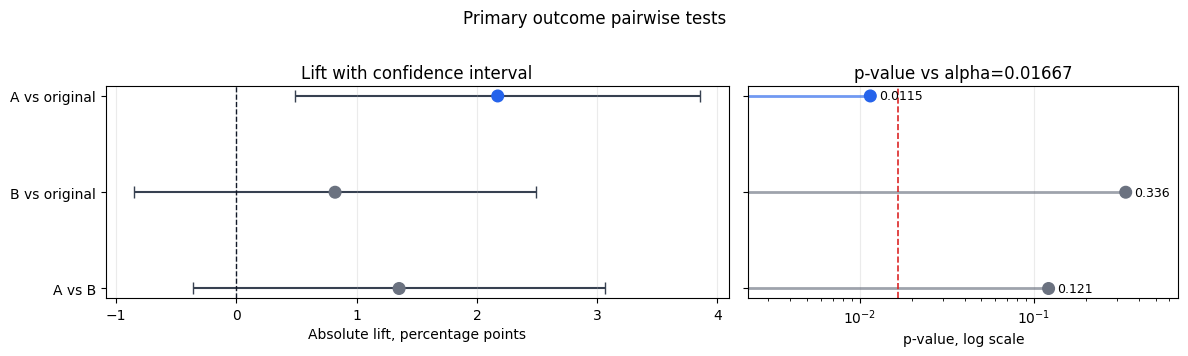

(<Figure size 1200x345 with 2 Axes>,
 (<Axes: title={'center': 'Lift with confidence interval'}, xlabel='Absolute lift, percentage points'>,
  <Axes: title={'center': 'p-value vs alpha=0.01667'}, xlabel='p-value, log scale'>))

In [11]:
plot_hypothesis_results(
    primary_tests,
    significance_level=0.05 / 3,
    title='Primary outcome pairwise tests',
)

### Delivered-Only Sensitivity Check

In [12]:
delivered_app = app[app['delivered'] == 1].copy()
delivered_summary = delivered_app.groupby('variant')[primary].agg(successes='sum', n='count', rate='mean').reindex(variants)
delivered_control_rate = delivered_summary.loc['original', 'rate']
delivered_summary['abs_lift_vs_original'] = delivered_summary['rate'] - delivered_control_rate
delivered_summary['rel_lift_vs_original'] = delivered_summary['abs_lift_vs_original'] / delivered_control_rate
display(delivered_summary.style.format('{:.4f}', subset=['rate', 'abs_lift_vs_original', 'rel_lift_vs_original']))

delivered_tests = pd.concat([
    hypothesis_test('original', 'A', primary, control_df=delivered_app[delivered_app['variant'] == 'original'], treatment_df=delivered_app[delivered_app['variant'] == 'A']),
    hypothesis_test('original', 'B', primary, control_df=delivered_app[delivered_app['variant'] == 'original'], treatment_df=delivered_app[delivered_app['variant'] == 'B']),
    hypothesis_test('B', 'A', primary, control_df=delivered_app[delivered_app['variant'] == 'B'], treatment_df=delivered_app[delivered_app['variant'] == 'A']),
], ignore_index=True)
delivered_tests['p_bonferroni'] = (delivered_tests['p_value'] * 3).clip(upper=1)
delivered_tests['significant_bonferroni'] = delivered_tests['p_bonferroni'] < 0.05
display(delivered_tests[['comparison','n_control','n_treat','x_control','x_treat','control_rate','treatment_rate','abs_lift','rel_lift','z_stat','p_value','p_bonferroni','significant_bonferroni','ci_low','ci_high']].style.format('{:.4f}', subset=['control_rate','treatment_rate','abs_lift','rel_lift','z_stat','p_value','p_bonferroni','ci_low','ci_high']))

,successes,n,rate,abs_lift_vs_original,rel_lift_vs_original
variant,,,,,
original,693,3957,0.1751,0.0000,0.0000
A,782,3940,0.1985,0.0233,0.1333
B,707,3843,0.1840,0.0088,0.0505


,comparison,n_control,n_treat,x_control,x_treat,control_rate,treatment_rate,abs_lift,rel_lift,z_stat,p_value,p_bonferroni,significant_bonferroni,ci_low,ci_high
0,A vs original,3957,3940,693,782,0.1751,0.1985,0.0233,0.1333,2.6614,0.0078,0.0233,True,0.0062,0.0405
1,B vs original,3957,3843,693,707,0.1751,0.1840,0.0088,0.0505,1.0169,0.3092,0.9276,False,-0.0082,0.0259
2,A vs B,3843,3940,707,782,0.1840,0.1985,0.0145,0.0789,1.6267,0.1038,0.3114,False,-0.0030,0.0320


### Visualization: Primary Outcome

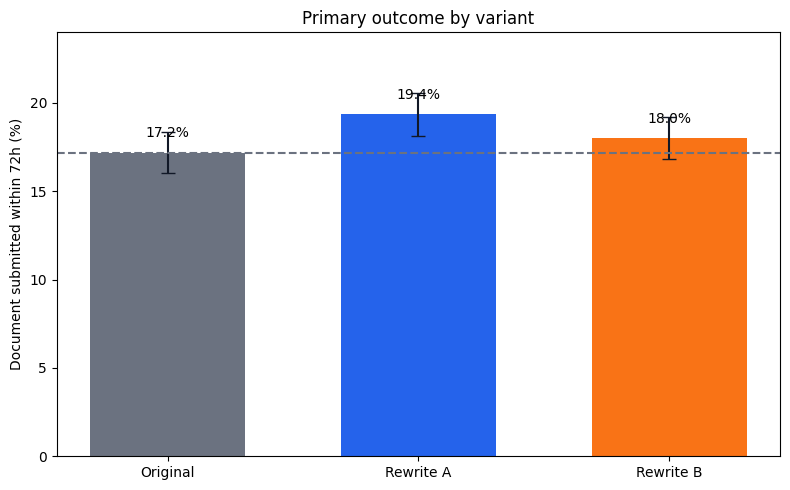

In [13]:
primary_plot = primary_summary.copy()
primary_plot['ci_low'] = [
    max(0, rate - 1.96 * np.sqrt(rate * (1 - rate) / n))
    for rate, n in zip(primary_plot['rate'], primary_plot['n'])
]
primary_plot['ci_high'] = [
    min(1, rate + 1.96 * np.sqrt(rate * (1 - rate) / n))
    for rate, n in zip(primary_plot['rate'], primary_plot['n'])
]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#6b7280', '#2563eb', '#f97316']
labels = ['Original', 'Rewrite A', 'Rewrite B']
x = np.arange(len(variants))
rates = primary_plot['rate'].values * 100
yerr = np.vstack((
    (primary_plot['rate'] - primary_plot['ci_low']).values * 100,
    (primary_plot['ci_high'] - primary_plot['rate']).values * 100,
))
bars = ax.bar(x, rates, color=colors, width=0.62)
ax.errorbar(x, rates, yerr=yerr, fmt='none', ecolor='#111827', capsize=5)
ax.axhline(primary_plot.loc['original', 'rate'] * 100, color='#6b7280', linestyle='--')
ax.set_xticks(x, labels)
ax.set_ylabel('Document submitted within 72h (%)')
ax.set_title('Primary outcome by variant')
ax.set_ylim(0, max((primary_plot['ci_high'] * 100).max() + 3, 24))
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.7, f'{rate:.1f}%', ha='center', va='bottom')
plt.tight_layout()
plt.show()

### Guardrails

In [14]:
guardrails = ['unsub_7d', 'complaint_7d', 'support_contact_7d']
guardrail_rates = app.groupby('variant')[guardrails].mean().reindex(variants)
guardrail_counts = app.groupby('variant')[guardrails].sum().reindex(variants)
display(guardrail_rates.style.format('{:.4%}'))
display(guardrail_counts)

guardrail_tests = pd.concat([
    hypothesis_test(
        control,
        treatment,
        metric,
        control_df=app[app['variant'] == control],
        treatment_df=app[app['variant'] == treatment],
    )
    for metric in guardrails
    for control, treatment in [('original', 'A'), ('original', 'B'), ('B', 'A')]
], ignore_index=True)
display(guardrail_tests[['metric','comparison','control_rate','treatment_rate','abs_lift','rel_lift','z_stat','p_value','ci_low','ci_high']].style.format('{:.4f}', subset=['control_rate','treatment_rate','abs_lift','rel_lift','z_stat','p_value','ci_low','ci_high']))

,unsub_7d,complaint_7d,support_contact_7d
variant,,,
original,0.2480%,0.1240%,2.2068%
A,0.4455%,0.1980%,1.9307%
B,0.8658%,0.2292%,3.0812%


,unsub_7d,complaint_7d,support_contact_7d
variant,,,
original,10,5,89
A,18,8,78
B,34,9,121


,metric,comparison,control_rate,treatment_rate,abs_lift,rel_lift,z_stat,p_value,ci_low,ci_high
0,unsub_7d,A vs original,0.0025,0.0045,0.0020,0.7969,1.5099,0.1311,-0.0006,0.0045
1,unsub_7d,B vs original,0.0025,0.0087,0.0062,2.4918,3.7171,0.0002,0.0029,0.0095
2,unsub_7d,A vs B,0.0087,0.0045,-0.0042,-0.4854,-2.3289,0.0199,-0.0078,-0.0007
3,complaint_7d,A vs original,0.0012,0.0020,0.0007,0.5972,0.8296,0.4068,-0.0010,0.0025
4,complaint_7d,B vs original,0.0012,0.0023,0.0011,0.8486,1.1200,0.2627,-0.0008,0.0029
5,complaint_7d,A vs B,0.0023,0.0020,-0.0003,-0.1360,-0.3014,0.7631,-0.0023,0.0017
6,support_contact_7d,A vs original,0.0221,0.0193,-0.0028,-0.1251,-0.8715,0.3835,-0.0090,0.0034
7,support_contact_7d,B vs original,0.0221,0.0308,0.0087,0.3962,2.4337,0.0149,0.0017,0.0158
8,support_contact_7d,A vs B,0.0308,0.0193,-0.0115,-0.3734,-3.2899,0.0010,-0.0184,-0.0046


### Visualization: Guardrails

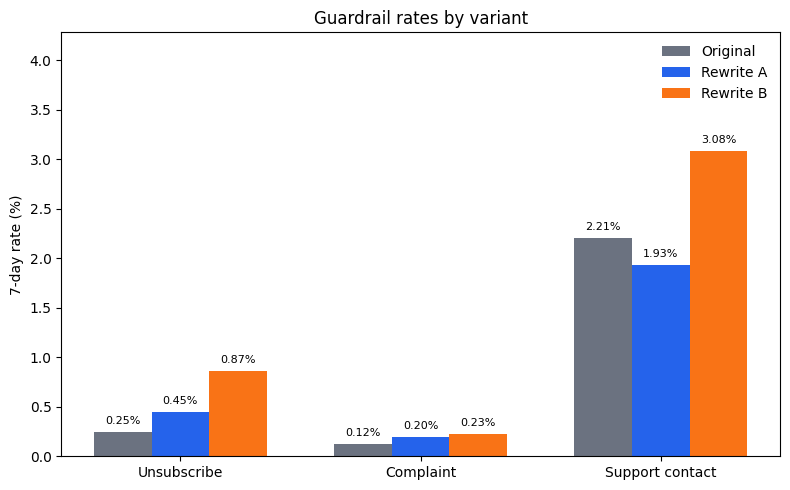

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
metric_labels = ['Unsubscribe', 'Complaint', 'Support contact']
width = 0.24
x = np.arange(len(guardrails))
colors = ['#6b7280', '#2563eb', '#f97316']
labels = ['Original', 'Rewrite A', 'Rewrite B']

for i, variant in enumerate(variants):
    values = guardrail_rates.loc[variant].values * 100
    ax.bar(x + (i - 1) * width, values, width=width, label=labels[i], color=colors[i])
    for j, value in enumerate(values):
        ax.text(j + (i - 1) * width, value + 0.08, f'{value:.2f}%', ha='center', fontsize=8)

ax.set_xticks(x, metric_labels)
ax.set_ylabel('7-day rate (%)')
ax.set_title('Guardrail rates by variant')
ax.legend(frameon=False)
ax.set_ylim(0, max(guardrail_rates.max().max() * 100 + 1.2, 4))
plt.tight_layout()
plt.show()

### Segment Review

In [16]:
for col in ['channel', 'risk_band', 'missing_doc_type']:
    segment = app.groupby([col, 'variant'])[primary].agg(successes='sum', n='count', rate='mean').reset_index()
    control = segment[segment['variant'] == 'original'][[col, 'rate']].rename(columns={'rate':'original_rate'})
    segment = segment.merge(control, on=col)
    segment['abs_lift_vs_original'] = segment['rate'] - segment['original_rate']
    print('\n' + col)
    display(segment.pivot(index=col, columns='variant', values='rate').style.format('{:.2%}'))
    display(segment.pivot(index=col, columns='variant', values='abs_lift_vs_original').style.format('{:.2%}'))


channel


variant,A,B,original
channel,,,
email,17.75%,17.67%,13.71%
sms,20.04%,18.16%,18.74%


variant,A,B,original
channel,,,
email,4.04%,3.96%,0.00%
sms,1.31%,-0.58%,0.00%



risk_band


variant,A,B,original
risk_band,,,
high,12.47%,13.64%,11.63%
low,22.81%,19.59%,19.56%
medium,18.73%,18.43%,17.00%


variant,A,B,original
risk_band,,,
high,0.84%,2.01%,0.00%
low,3.25%,0.03%,0.00%
medium,1.73%,1.43%,0.00%



missing_doc_type


variant,A,B,original
missing_doc_type,,,
bank_statement,21.57%,18.63%,18.03%
both,15.59%,15.55%,14.77%
paystub,19.96%,18.93%,17.98%


variant,A,B,original
missing_doc_type,,,
bank_statement,3.54%,0.60%,0.00%
both,0.81%,0.78%,0.00%
paystub,1.99%,0.95%,0.00%


### Visualization: Segment Lift

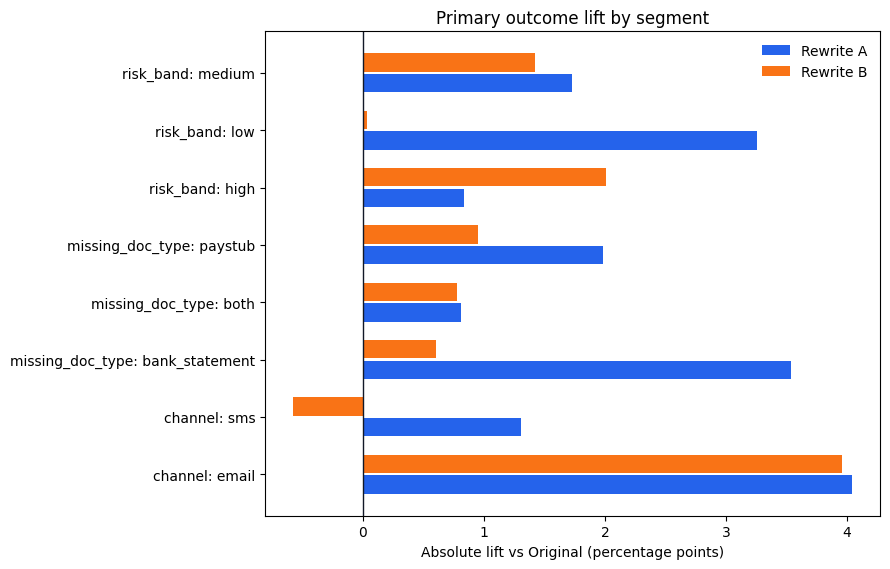

In [17]:
segment_frames = []
for col in ['channel', 'risk_band', 'missing_doc_type']:
    segment = app.groupby([col, 'variant'])[primary].agg(successes='sum', n='count', rate='mean').reset_index()
    control = segment[segment['variant'] == 'original'][[col, 'rate']].rename(columns={'rate': 'original_rate'})
    segment = segment.merge(control, on=col)
    segment['abs_lift_vs_original'] = segment['rate'] - segment['original_rate']
    segment = segment[segment['variant'].isin(['A', 'B'])].copy()
    segment['segment'] = col + ': ' + segment[col].astype(str)
    segment_frames.append(segment[['segment', 'variant', 'abs_lift_vs_original']])

segment_plot = pd.concat(segment_frames, ignore_index=True)
segment_pivot = segment_plot.pivot(index='segment', columns='variant', values='abs_lift_vs_original').sort_index()

fig, ax = plt.subplots(figsize=(9, 5.8))
y = np.arange(len(segment_pivot.index))
ax.axvline(0, color='#111827', linewidth=1)
ax.barh(y - 0.18, segment_pivot['A'] * 100, height=0.32, label='Rewrite A', color='#2563eb')
ax.barh(y + 0.18, segment_pivot['B'] * 100, height=0.32, label='Rewrite B', color='#f97316')
ax.set_yticks(y, segment_pivot.index)
ax.set_xlabel('Absolute lift vs Original (percentage points)')
ax.set_title('Primary outcome lift by segment')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Segment Hypothesis Tests

In [18]:
segment_tests = pd.concat([
    hypothesis_test(
        'original',
        'A',
        primary,
        control_df=app[(app['risk_band'] == 'high') & (app['variant'] == 'original')],
        treatment_df=app[(app['risk_band'] == 'high') & (app['variant'] == 'A')],
    ).assign(segment='High risk'),
    hypothesis_test(
        'original',
        'A',
        primary,
        control_df=app[(app['missing_doc_type'] == 'both') & (app['variant'] == 'original')],
        treatment_df=app[(app['missing_doc_type'] == 'both') & (app['variant'] == 'A')],
    ).assign(segment='Missing both docs'),
    hypothesis_test(
        'original',
        'A',
        primary,
        control_df=app[(app['channel'] == 'sms') & (app['variant'] == 'original')],
        treatment_df=app[(app['channel'] == 'sms') & (app['variant'] == 'A')],
    ).assign(segment='SMS channel'),
], ignore_index=True)

segment_tests = segment_tests[
    ['segment', 'comparison', 'n_control', 'n_treat', 'control_rate',
     'treatment_rate', 'abs_lift', 'rel_lift', 'p_value', 'ci_low', 'ci_high']
]

display(segment_tests.style.format('{:.3f}', subset=[
    'control_rate', 'treatment_rate', 'abs_lift', 'rel_lift',
    'p_value', 'ci_low', 'ci_high'
]).set_table_styles([
    {'selector': 'th', 'props': [('white-space', 'nowrap'), ('width', 'auto')]},
    {'selector': 'td', 'props': [('white-space', 'nowrap'), ('width', 'auto')]},
]))

,segment,comparison,n_control,n_treat,control_rate,treatment_rate,abs_lift,rel_lift,p_value,ci_low,ci_high
0,High risk,A vs original,748,802,0.116,0.125,0.008,0.072,0.613,-0.024,0.041
1,Missing both docs,A vs original,1022,1065,0.148,0.156,0.008,0.055,0.605,-0.023,0.039
2,SMS channel,A vs original,2786,2829,0.187,0.200,0.013,0.070,0.216,-0.008,0.034


### Visualization: Segment Hypothesis Tests

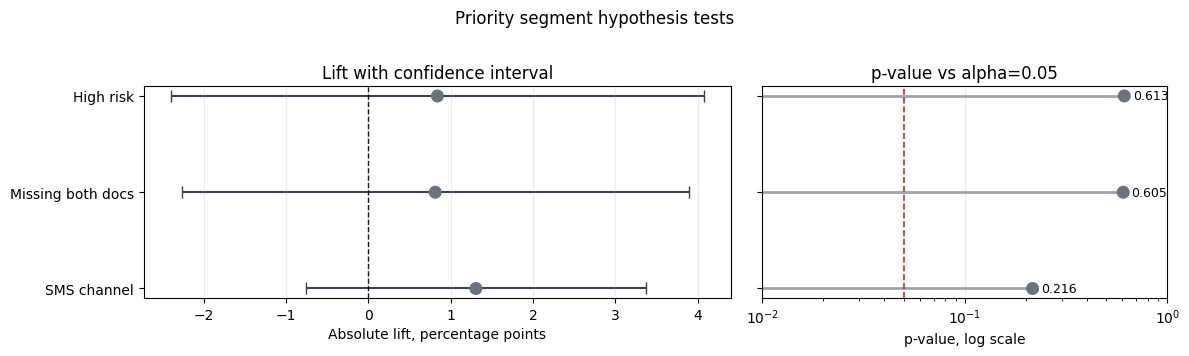

(<Figure size 1200x345 with 2 Axes>,
 (<Axes: title={'center': 'Lift with confidence interval'}, xlabel='Absolute lift, percentage points'>,
  <Axes: title={'center': 'p-value vs alpha=0.05'}, xlabel='p-value, log scale'>))

In [19]:
plot_hypothesis_results(
    segment_tests,
    significance_level=0.05,
    title='Priority segment hypothesis tests',
)

### Segment-level conclusion

The segment-level results do **not** show strong evidence that Variant A behaves differently from the Original in the three watch areas reviewed: **high-risk borrowers**, **applicants missing both documents**, and the **SMS channel**.

1. **All three subgroup lifts are positive**  
   In each segment, the observed lift for A is still above zero, so there is no descriptive sign that A is clearly underperforming the Original in these groups.

2. **Confidence intervals are wide and cross zero**  
   For all three segments, the confidence intervals extend across zero. This means the true effect in each subgroup could be slightly negative or positive, so the estimates are too uncertain to support a strong subgroup-specific claim.

3. **None of the subgroup p-values is significant**  
   The p-values for all three subgroup tests are above 0.05:
   - High risk: **0.613**
   - Missing both docs: **0.605**
   - SMS channel: **0.216**

   So we do not have statistically reliable evidence that A improves the primary outcome within these individual subgroups.

4. **Interpretation for rollout**  
   These subgroup results do **not** overturn A’s overall win, but they do show that the evidence is weaker in these segments than in the full sample. So the right conclusion is not that A fails in these groups, but that these groups should be **monitored more closely during rollout**.

### Practical takeaway

Variant A remains the best overall candidate, but for **high-risk borrowers**, **missing-both-docs applicants**, and the **SMS channel**, the subgroup evidence is too uncertain to make strong claims. These segments should therefore be treated as **caution areas for rollout**, with closer monitoring of primary outcome and guardrails.

## Part B - Written Recommendation

Recommend Variant A as the winning candidate. Variant A improves `doc_submitted_72h` from 17.18% to 19.36%, an absolute lift of 2.17 percentage points and a relative lift of 12.65% versus Original. The A vs Original confidence interval for the lift is positive, and the result remains statistically significant after Bonferroni correction for the three pairwise primary-outcome comparisons.

Variant B should not be rolled out. It has a smaller and statistically inconclusive primary-outcome lift, while its unsubscribe and support-contact rates are directionally worse than Original.

Recommendation: roll out Variant A with monitoring rather than rolling out B. Monitor unsubscribe, complaint, and support-contact guardrails after launch. Segment-level results should be treated as directional because each subgroup has less sample than the overall experiment.

## Drawing conclusions

### 1. Primary outcome: `doc_submitted_72h` — Original vs A

Since the **p-value = 0.0115** is below the Bonferroni-adjusted threshold of **0.0167**, we **reject the null hypothesis** for **A vs Original**. This means Rewrite **A performed significantly better** than the Original on the primary outcome.

If we look at the effect size, Rewrite A improved the submission rate from **17.18%** to **19.36%**, which is:

- **+2.17 percentage points** absolute lift
- about **+12.65%** relative lift

The confidence interval for the difference is **[0.0049, 0.0386]**, or about **[+0.49 pp, +3.86 pp]**. This is important because:

- it is entirely **above zero**
- so the true effect is likely **positive**
- and the improvement is not only statistically significant, but also looks **practically meaningful**

So based on the primary metric, **A is a credible improvement over the Original**.

---

### 2. Primary outcome: `doc_submitted_72h` — Original vs B

Since the **p-value = 0.3365** is far above the Bonferroni-adjusted threshold of **0.0167**, we **cannot reject the null hypothesis** for **B vs Original**. This means Rewrite **B did not perform significantly differently** from the Original on the primary outcome.

Rewrite B improved the submission rate only from **17.18%** to **18.00%**, which is:

- **+0.82 percentage points** absolute lift
- about **+4.77%** relative lift

However, the confidence interval for the difference is **[-0.0085, 0.0249]**, or about **[-0.85 pp, +2.49 pp]**. This means:

- it **includes zero**
- so the true effect could be slightly **negative** or slightly **positive**
- therefore the result is **inconclusive**

So based on the primary metric, **B is not a reliable improvement over the Original**.

---

### 3. Guardrail: `unsub_7d` — Original vs A

For unsubscribe rate, the **p-value = 0.1311**, which is above the Bonferroni-adjusted threshold. So we **cannot conclude that A significantly worsens unsubscribes** relative to the Original.

The unsubscribe rate increased from **0.25%** to **0.45%**, which looks directionally worse, but the confidence interval for the difference is **[-0.0006, 0.0045]**. Because this interval includes zero:

- the increase is **not statistically reliable**
- the evidence is not strong enough to say that A truly worsens this guardrail

So unsubscribe risk for A should be **monitored**, but it is **not strong enough to overturn the primary win**.

---

### 4. Guardrail: `support_contact_7d` — Original vs A

For support-contact rate, the **p-value = 0.3835**, so again we **cannot reject the null hypothesis**. In fact, the direction here is slightly favorable to A:

- Original: **2.21%**
- A: **1.93%**

That is an absolute difference of about **-0.28 percentage points**, meaning A may even reduce support burden slightly. But the confidence interval **[-0.0090, 0.0034]** includes zero, so this effect is also **not statistically reliable**.

So the safest conclusion is:

- A does **not appear to worsen support-contact rate**
- but we also cannot claim a reliable improvement there

---

## Final interpretation

Putting this together:

- **Rewrite A** is the strongest candidate because it shows a **meaningful and statistically reliable lift** in the primary outcome
- its guardrails do **not show statistically significant deterioration**
- **Rewrite B** does not show reliable improvement on the primary outcome, so it is not a strong candidate based on these results

## Suggested final recommendation

A good final write-up would be:

> Variant A appears to be the best candidate. It improves the primary outcome from **17.18%** to **19.36%**, a **+2.17 percentage-point** absolute lift, and this effect remains statistically significant after Bonferroni correction. In contrast, Variant B shows only a small lift and does not significantly differ from the Original. On the guardrails reviewed so far, A does not show statistically significant worsening, although unsubscribe should continue to be monitored. Based on these results, A is the most defensible winner at this stage.